In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import cv2
from collections import Counter

# Load the processed CSV files
processed_data_dir = "Processed Data"
images_file = os.path.join(processed_data_dir, "floorplan_images.csv")
human_annotations_file = os.path.join(processed_data_dir, "human_annotations.csv")
artificial_annotations_file = os.path.join(processed_data_dir, "artificial_annotations.csv")

images_df = pd.read_csv(images_file)
human_annotations_df = pd.read_csv(human_annotations_file)
artificial_annotations_df = pd.read_csv(artificial_annotations_file)

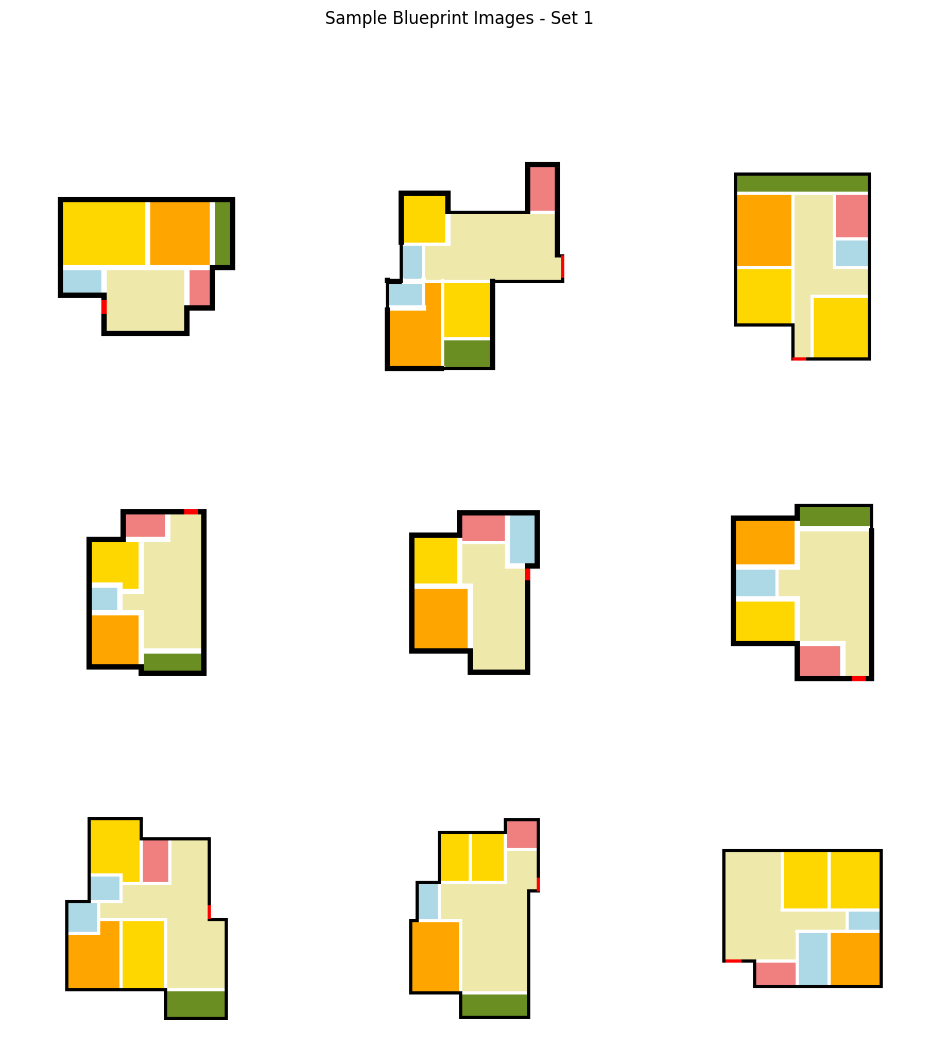

In [33]:
# Visualizing Blueprint Images
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img_path = images_df['image_path'].iloc[i]
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Sample Blueprint Images - Set 1')
plt.show(block=True)

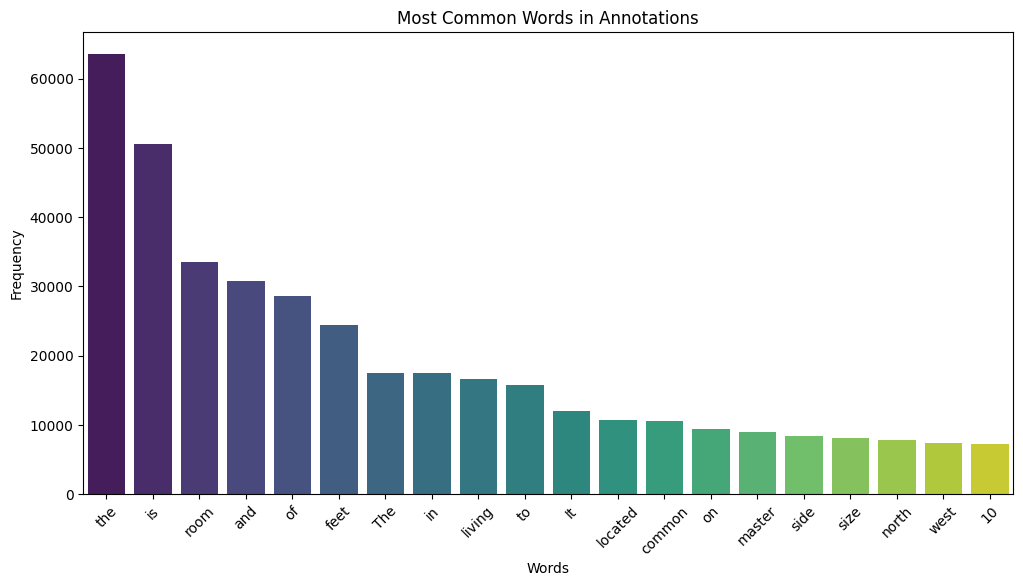

In [34]:
# Annotation Distribution - Word Frequency Analysis
all_annotations = pd.concat([human_annotations_df['annotation'], artificial_annotations_df['artificial_description']]).dropna()
word_list = []
for annotation in all_annotations:
    word_list.extend(str(annotation).split())
word_counts = Counter(word_list)
most_common_words = dict(word_counts.most_common(20))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(most_common_words.keys()), y=list(most_common_words.values()), hue=list(most_common_words.keys()), dodge=False, palette='viridis', legend=False)
plt.title('Most Common Words in Annotations')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.xlabel('Words')
plt.show(block=True)

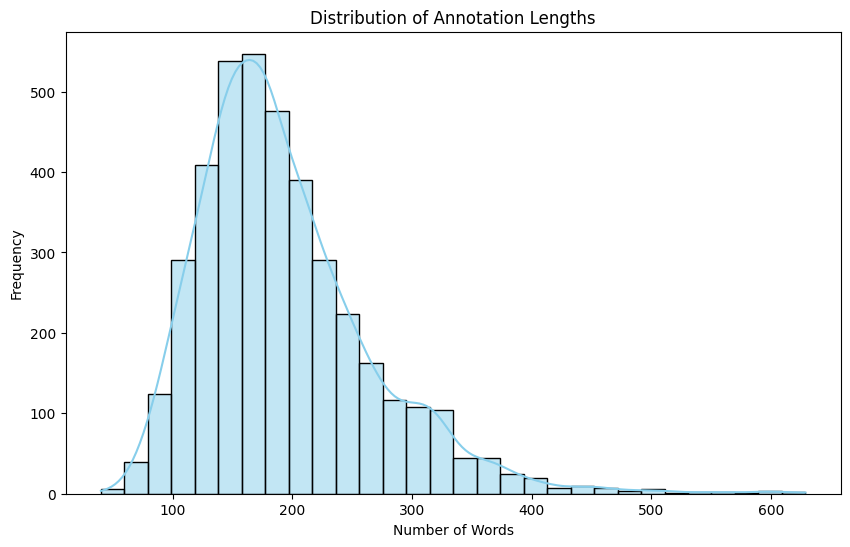

In [35]:
# Length Distribution of Annotations
annotation_lengths = all_annotations.apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.histplot(annotation_lengths, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Annotation Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show(block=True)

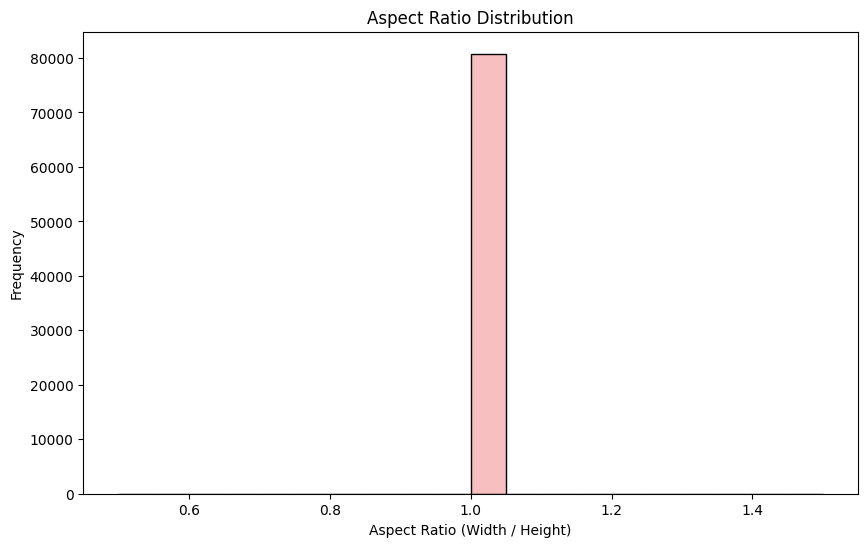

In [36]:
# Aspect Ratio Distribution
aspect_ratios = [w / h for w, h in image_resolutions]
plt.figure(figsize=(10, 6))
sns.histplot(aspect_ratios, bins=20, kde=True, color='lightcoral')
plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Frequency')
plt.show(block=True)

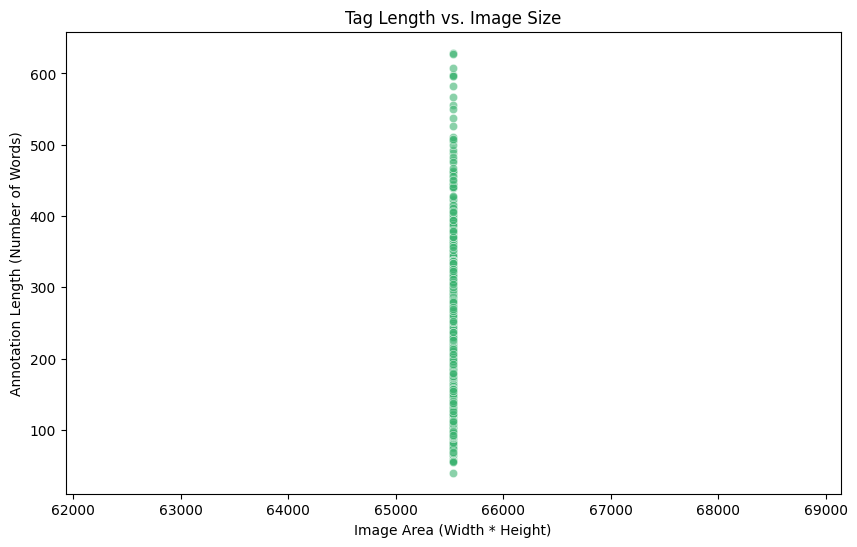

In [37]:
# Correlation Between Tag Length and Image Size
image_areas = [w * h for w, h in image_resolutions]
tag_lengths = human_annotations_df['annotation'].dropna().apply(lambda x: len(str(x).split()))

if len(image_areas) >= len(tag_lengths):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=image_areas[:len(tag_lengths)], y=tag_lengths, alpha=0.6, color='mediumseagreen')
    plt.title('Tag Length vs. Image Size')
    plt.xlabel('Image Area (Width * Height)')
    plt.ylabel('Annotation Length (Number of Words)')
    plt.show(block=True)
else:
    print("Insufficient data for correlation analysis between tag length and image size.")

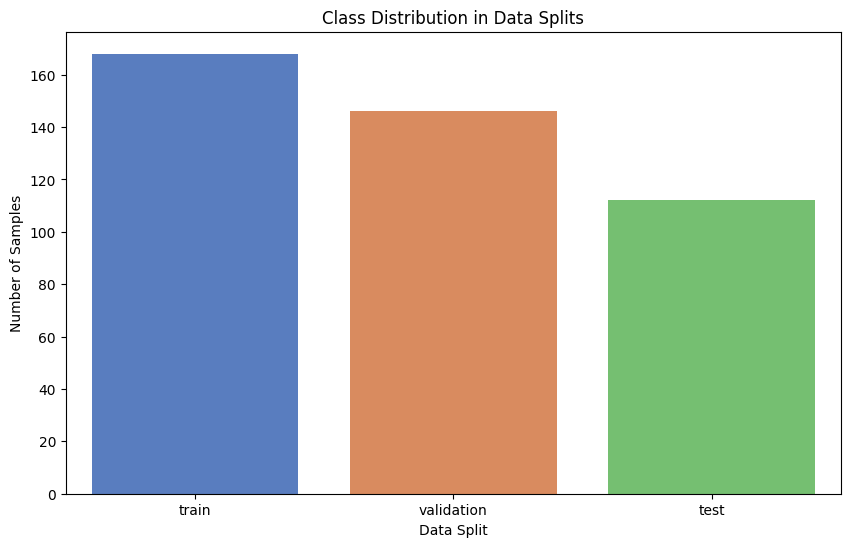

In [38]:
# Class Distribution in Splits (Mock Splits)
splits = ['train', 'validation', 'test']
split_counts = np.random.randint(100, 200, size=3)
plt.figure(figsize=(10, 6))
sns.barplot(x=splits, y=split_counts, hue=splits, dodge=False, palette='muted', legend=False)
plt.title('Class Distribution in Data Splits')
plt.ylabel('Number of Samples')
plt.xlabel('Data Split')
plt.show(block=True)